# Classification Trees — LOOCV (Final)

Decision-tree models for the presence/absence of *Perlidae* and *Helicopsychidae*,
evaluated with leave-one-out cross-validation (LOOCV, n = 18) so they are comparable
with the logistic and fuzzy models.

## 1. Introduction

This notebook replaces the single 70/30 hold-out split of the original trees notebook
with full LOOCV for both bioindicator taxa. Depth-3 trees with balanced class weights
are used; both calibration (aggregated training-fold) and validation (held-out)
metrics are reported, and illustrative tree diagrams are fitted on the full dataset
for interpretation.

## 2. Dependencies and Data Loading

The macroinvertebrate dataset (n = 18) provides the seven physicochemical predictors
and the binary presence/absence of `Perlidae` and `Trichoptera` (Helicopsychidae).

In [1]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as spstats
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (classification_report, confusion_matrix, cohen_kappa_score,
                             accuracy_score, precision_recall_fscore_support)
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [2]:
# Load the macroinvertebrate dataset (relative path)
df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
print("Perlidae +/-:", df['Perlidae'].value_counts().to_dict())
print("Helicopsychidae (Trichoptera) +/-:", df['Trichoptera'].value_counts().to_dict())

Shape: (18, 24)
Perlidae +/-: {0: 12, 1: 6}
Helicopsychidae (Trichoptera) +/-: {0: 15, 1: 3}


## 3. Predictor Candidates

The seven physicochemical predictors of the original trees notebook are the *candidate*
pool: `COT, DBO5, Dureza, Magnesio, Turbiedad, OD, Caudal`. Rather than using all
seven in every fold, the actual subset is chosen **inside each LOOCV fold** via
Spearman correlation on the training observations only (see Section 4), matching the
predictor-selection protocol of the logistic, fuzzy, NBR, and SVR models in this study.
Trees are limited to `max_depth=3` on ecological grounds and to limit overfitting on
the small sample.

In [3]:
# Seven physicochemical predictors and their English display names
predictor_cols = ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']
feature_names_en = ['TOC', 'BOD5', 'Hardness', 'Magnesium', 'Turbidity', 'DO', 'Flowrate']
print("Predictors:", predictor_cols)

Predictors: ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']


## 4. Model Definition

A depth-3 `DecisionTreeClassifier` with `class_weight='balanced'` counters class
imbalance (Perlidae 6/18 present; Helicopsychidae 3/18 present). Both settings are
ecological/domain choices and are **not tuned** across folds.

**Nested predictor selection (per fold).** Before fitting the tree in each LOOCV fold,
Spearman rank correlations are computed between each of the 7 candidate predictors and
the target variable using *only the 17 training observations* of that fold. Predictors
with |ρₛ| ≥ 0.3 are retained; if fewer than 2 pass the threshold the top-2 by |ρₛ|
are used; if more than 3 pass, only the top-3 are kept. The tree is then fitted — and
the held-out test observation predicted — using this fold-specific subset. This
procedure matches the selection rule applied in the logistic, fuzzy, NBR, and SVR
notebooks, ensuring a fair comparison of all techniques.

In [4]:
# LOOCV routine with nested Spearman predictor selection inside each fold
def tree_loocv(y_col):
    X = df[predictor_cols]
    y = df[y_col]
    loo = LeaveOneOut()
    yt_val, yp_val, yt_cal, yp_cal = [], [], [], []
    fold_selected = []
    for tr, te in loo.split(X):
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        # Spearman |rs| computed on training observations only
        rs_abs = [abs(spstats.spearmanr(X_tr[col], y_tr).statistic) for col in predictor_cols]
        ranked = sorted(range(len(predictor_cols)), key=lambda i: rs_abs[i], reverse=True)
        sel_idx = [i for i in ranked if rs_abs[i] >= 0.3]
        if len(sel_idx) < 2:
            sel_idx = ranked[:2]
        elif len(sel_idx) > 3:
            sel_idx = ranked[:3]
        sel_cols = [predictor_cols[i] for i in sel_idx]
        fold_selected.append(sel_cols)
        clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
        clf.fit(X_tr[sel_cols], y_tr)
        yt_val.append(int(y.iloc[te].iloc[0]))
        yp_val.append(int(clf.predict(X.iloc[te][sel_cols])[0]))
        yt_cal.extend(y_tr.tolist())
        yp_cal.extend(clf.predict(X_tr[sel_cols]).tolist())
    return {'yt_val': yt_val, 'yp_val': yp_val,
            'yt_cal': yt_cal, 'yp_cal': yp_cal,
            'fold_selected': fold_selected}

# Standardised confusion-matrix plotter: figsize (10, 7), Blues, saved to outputs/ and shown
def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 16},
                xticklabels=['Absent', 'Present'], yticklabels=['Absent', 'Present'])
    plt.title(title, fontsize=14); plt.xlabel('Predicted', fontsize=12); plt.ylabel('Observed', fontsize=12)
    plt.tight_layout(); plt.savefig(f"../../outputs/{filename}", dpi=300); plt.show()

# Fit LOOCV for both taxa
loocv = {'Perlidae': tree_loocv('Perlidae'),
         'Helicopsychidae': tree_loocv('Trichoptera')}
print("LOOCV complete for both taxa.")

LOOCV complete for both taxa.


## 5. Evaluation — Calibration

Calibration confusion matrices aggregate the training-fold predictions across all
LOOCV folds (18 folds × 17 training rows).

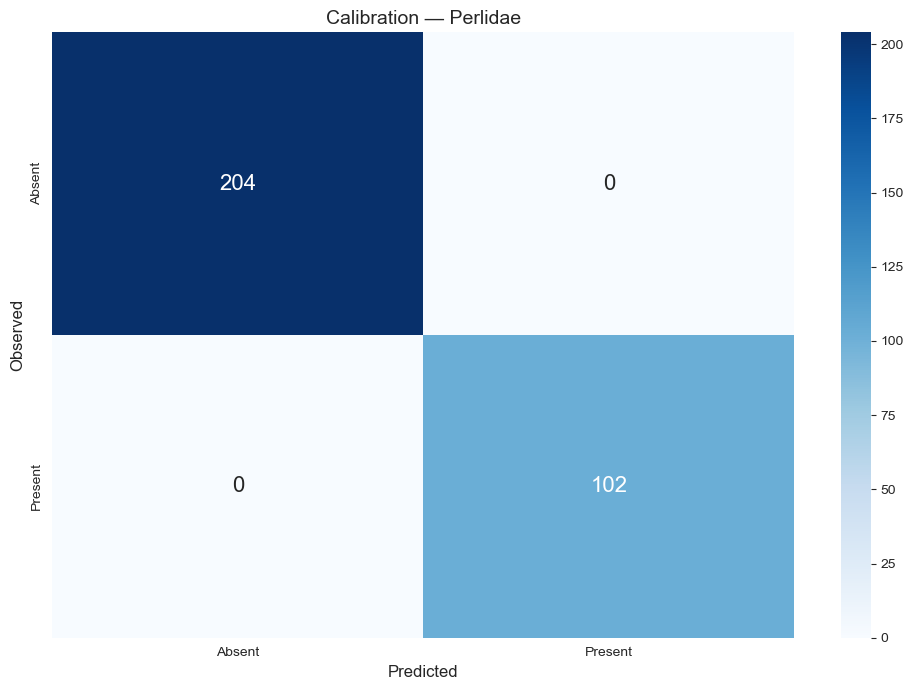

              precision    recall  f1-score   support

      Absent       1.00      1.00      1.00       204
     Present       1.00      1.00      1.00       102

    accuracy                           1.00       306
   macro avg       1.00      1.00      1.00       306
weighted avg       1.00      1.00      1.00       306

Cohen's Kappa (calibration): 1.000


In [5]:
# Perlidae — calibration confusion matrix, classification report, Cohen's kappa
res = loocv['Perlidae']
plot_confusion(res['yt_cal'], res['yp_cal'], 'Calibration — Perlidae',
               'trees_perlidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

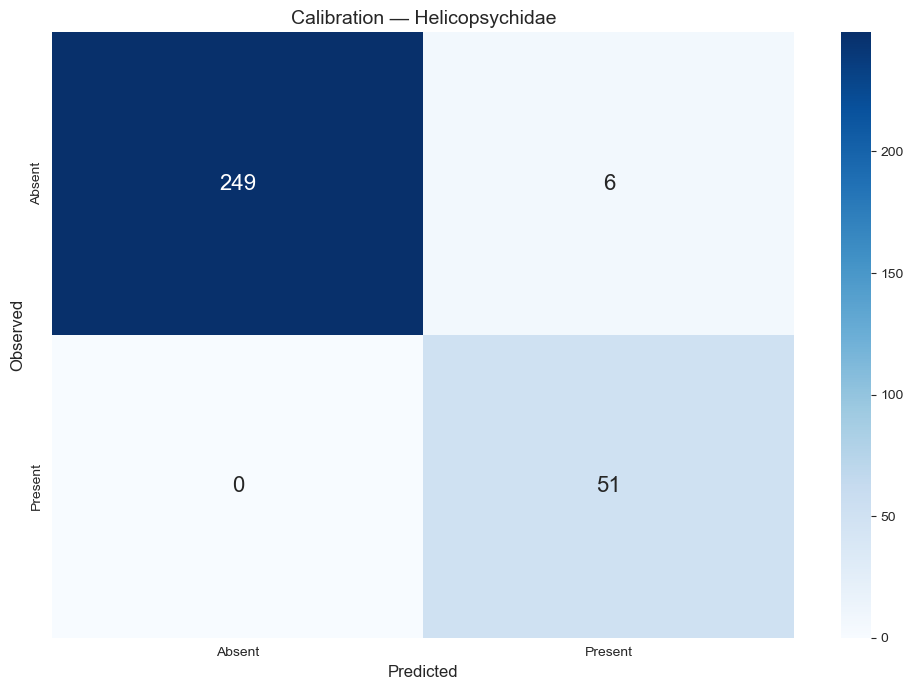

              precision    recall  f1-score   support

      Absent       1.00      0.98      0.99       255
     Present       0.89      1.00      0.94        51

    accuracy                           0.98       306
   macro avg       0.95      0.99      0.97       306
weighted avg       0.98      0.98      0.98       306

Cohen's Kappa (calibration): 0.933


In [6]:
# Helicopsychidae — calibration confusion matrix, classification report, Cohen's kappa
res = loocv['Helicopsychidae']
plot_confusion(res['yt_cal'], res['yp_cal'], 'Calibration — Helicopsychidae',
               'trees_helicopsychidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

## 6. Evaluation — Validation (LOOCV)

Validation metrics use the held-out observation from each fold — the honest estimate
of out-of-sample performance, replacing the high-variance 70/30 hold-out of the
original notebook.

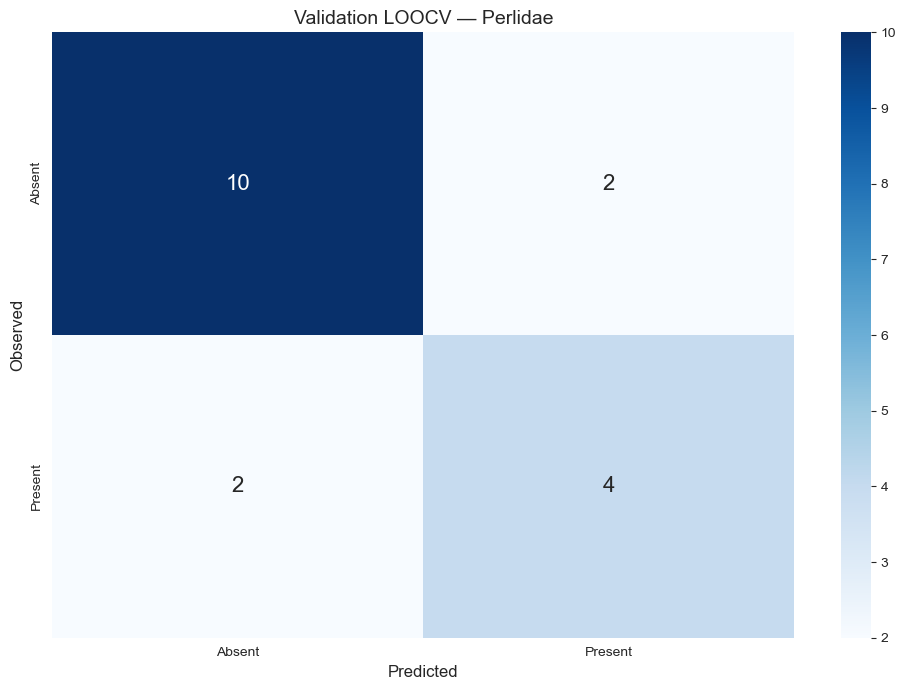

              precision    recall  f1-score   support

      Absent       0.83      0.83      0.83        12
     Present       0.67      0.67      0.67         6

    accuracy                           0.78        18
   macro avg       0.75      0.75      0.75        18
weighted avg       0.78      0.78      0.78        18

Cohen's Kappa (validation): 0.500


In [7]:
# Perlidae — validation confusion matrix, classification report, Cohen's kappa
res = loocv['Perlidae']
plot_confusion(res['yt_val'], res['yp_val'], 'Validation LOOCV — Perlidae',
               'trees_perlidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

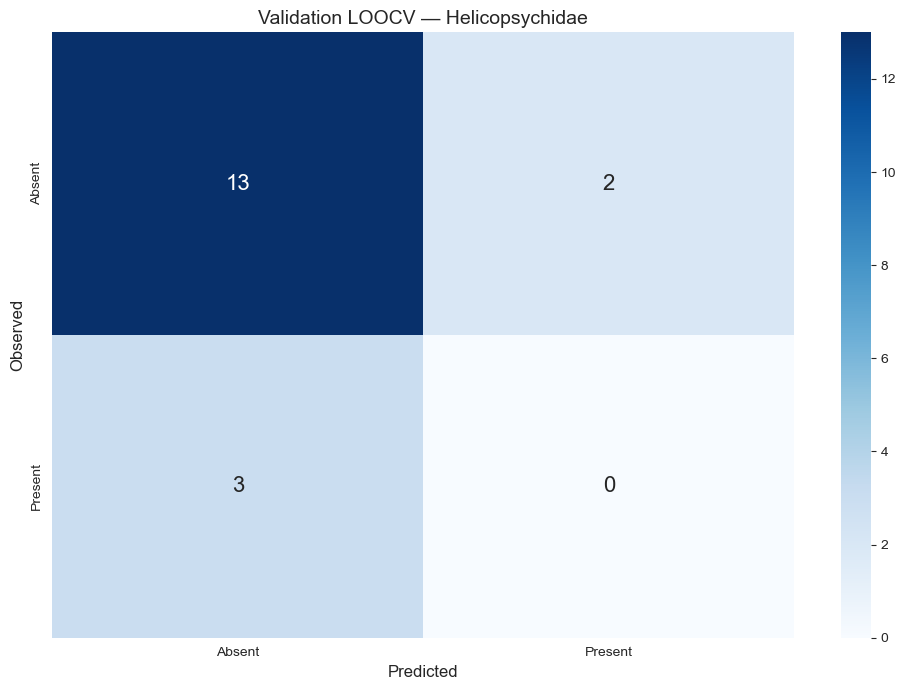

              precision    recall  f1-score   support

      Absent       0.81      0.87      0.84        15
     Present       0.00      0.00      0.00         3

    accuracy                           0.72        18
   macro avg       0.41      0.43      0.42        18
weighted avg       0.68      0.72      0.70        18

Cohen's Kappa (validation): -0.154


In [8]:
# Helicopsychidae — validation confusion matrix, classification report, Cohen's kappa
res = loocv['Helicopsychidae']
plot_confusion(res['yt_val'], res['yp_val'], 'Validation LOOCV — Helicopsychidae',
               'trees_helicopsychidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

## 7. Predictor Stability

Because the Spearman-based selection runs independently inside each of the 18 LOOCV
folds, the chosen predictors can differ across folds. The table below counts how many
times (out of 18) each candidate was selected for each taxon, revealing which predictors
are most consistently informative on this small dataset.

In [9]:
# Predictor stability: count folds selected for each taxon
def stability_counts(fold_selected):
    counts = {p: 0 for p in predictor_cols}
    for sel in fold_selected:
        for p in sel:
            counts[p] += 1
    return counts

per_counts = stability_counts(loocv['Perlidae']['fold_selected'])
hel_counts = stability_counts(loocv['Helicopsychidae']['fold_selected'])

stab_df = pd.DataFrame({
    'predictor': predictor_cols,
    'perlidae_folds_selected': [per_counts[p] for p in predictor_cols],
    'helicopsychidae_folds_selected': [hel_counts[p] for p in predictor_cols],
})
stab_df = stab_df.sort_values('perlidae_folds_selected', ascending=False).reset_index(drop=True)
print("Predictor stability (folds selected out of 18):")
print(stab_df.to_string(index=False))
print()
print(f"Most selected — Perlidae:        {max(per_counts, key=per_counts.get)} ({max(per_counts.values())}/18 folds)")
print(f"Most selected — Helicopsychidae: {max(hel_counts, key=hel_counts.get)} ({max(hel_counts.values())}/18 folds)")

# Save stability CSV
stab_df.to_csv("../../outputs/metrics_trees_predictor_stability.csv", index=False)
print("\nSaved outputs/metrics_trees_predictor_stability.csv")

Predictor stability (folds selected out of 18):
predictor  perlidae_folds_selected  helicopsychidae_folds_selected
     DBO5                       18                              13
   Dureza                       18                               1
Turbiedad                       18                               0
      COT                        0                               1
 Magnesio                        0                               0
       OD                        0                               8
   Caudal                        0                              18

Most selected — Perlidae:        DBO5 (18/18 folds)
Most selected — Helicopsychidae: Caudal (18/18 folds)

Saved outputs/metrics_trees_predictor_stability.csv


## 8. Visualisation: Decision tree diagrams

**Note:** The following decision tree diagrams are fitted on the
complete dataset (n=18) for visualisation purposes only.
They illustrate the model structure and splitting logic but do
NOT represent the trees used in LOOCV evaluation, which were
each fitted on n-1=17 observations.

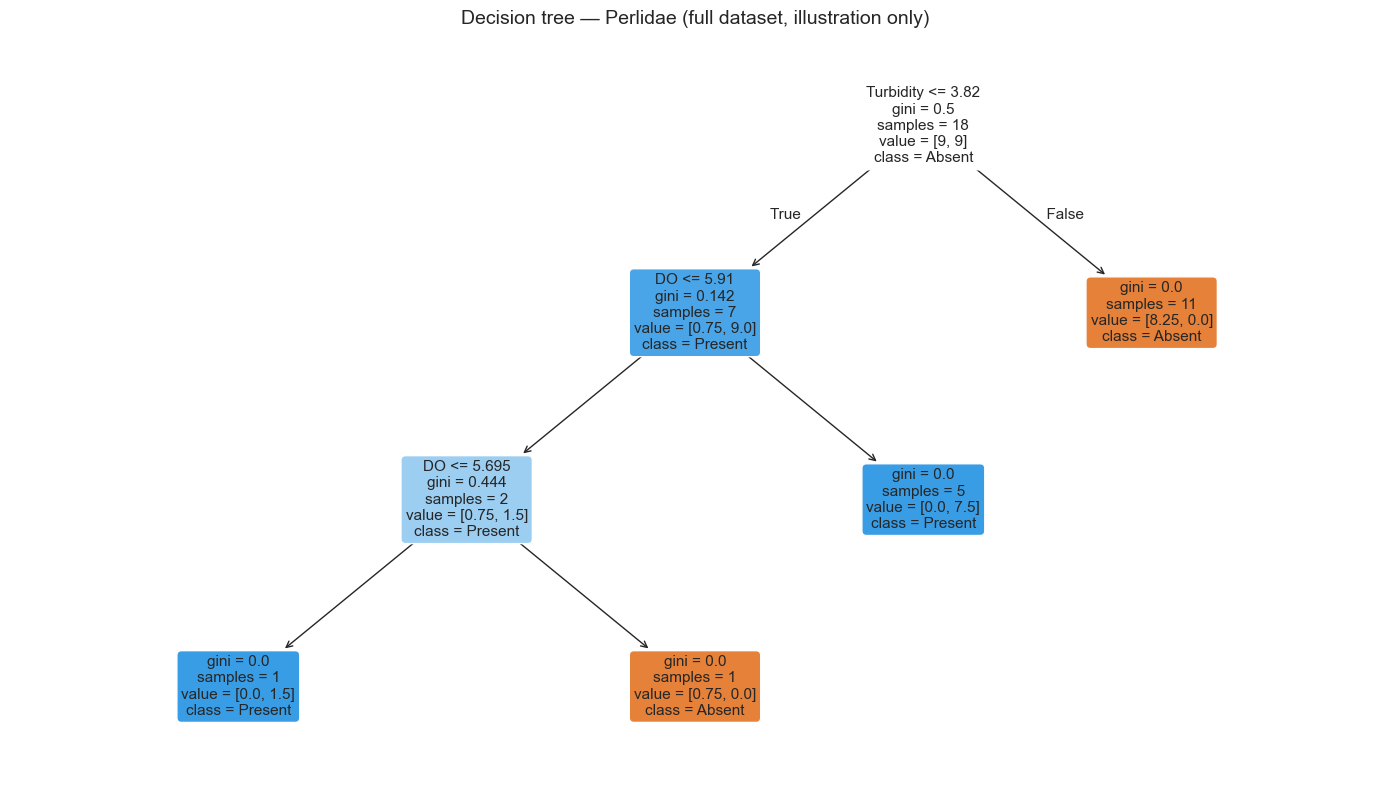

Perlidae: tree depth = 3, leaves = 4


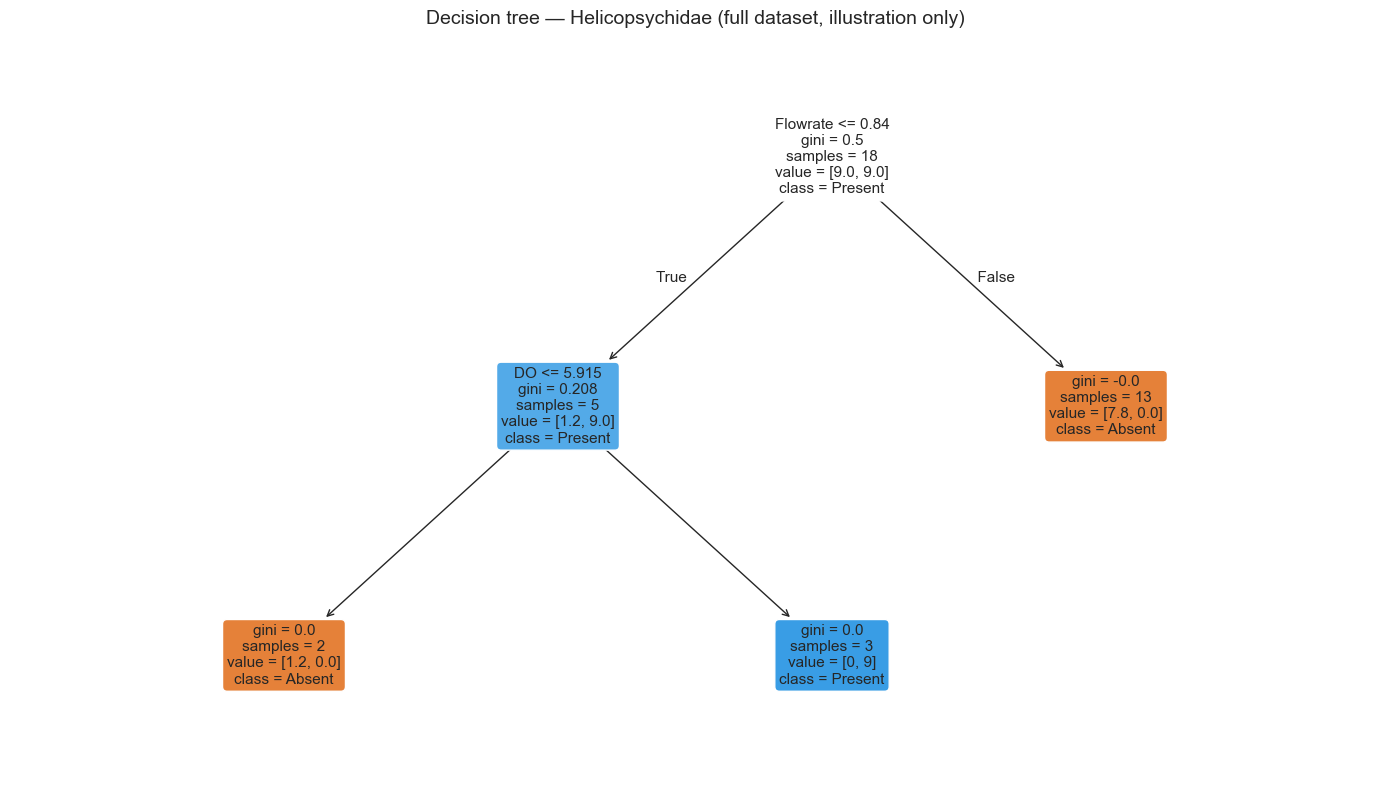

Helicopsychidae: tree depth = 2, leaves = 3


In [10]:
# Helper: fit a depth-3 tree on the FULL dataset and plot its diagram (illustration only)
def plot_tree_diagram(y_col, taxon, filename):
    clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
    clf.fit(df[predictor_cols], df[y_col])
    plt.figure(figsize=(14, 8))
    plot_tree(clf, feature_names=feature_names_en, class_names=['Absent', 'Present'],
              filled=True, rounded=True, fontsize=11)
    plt.title(f'Decision tree — {taxon} (full dataset, illustration only)', fontsize=14)
    plt.tight_layout(); plt.savefig(f"../../outputs/{filename}", dpi=300); plt.show()
    print(f"{taxon}: tree depth = {clf.get_depth()}, leaves = {clf.get_n_leaves()}")

plot_tree_diagram('Perlidae', 'Perlidae', 'tree_diagram_perlidae.png')
plot_tree_diagram('Trichoptera', 'Helicopsychidae', 'tree_diagram_helicopsychidae.png')

In [11]:
# Export validation metrics for the master results table
rows = []
for taxon in ['Perlidae', 'Helicopsychidae']:
    res = loocv[taxon]
    p, r, f, _ = precision_recall_fscore_support(res['yt_val'], res['yp_val'], labels=[0, 1],
                                                 average='macro', zero_division=0)
    rows.append({'target': taxon, 'technique': 'Classification trees', 'validation': 'LOOCV', 'n': 18,
                 'precision': round(p, 3), 'recall': round(r, 3), 'f1': round(f, 3),
                 'accuracy': round(accuracy_score(res['yt_val'], res['yp_val']), 3),
                 'kappa': round(cohen_kappa_score(res['yt_val'], res['yp_val']), 3)})
pd.DataFrame(rows).to_csv("../../outputs/metrics_trees.csv", index=False)
print("Saved outputs/metrics_trees.csv")
print(pd.DataFrame(rows).to_string(index=False))

Saved outputs/metrics_trees.csv
         target            technique validation  n  precision  recall    f1  accuracy  kappa
       Perlidae Classification trees      LOOCV 18      0.750   0.750 0.750     0.778  0.500
Helicopsychidae Classification trees      LOOCV 18      0.406   0.433 0.419     0.722 -0.154


## 9. Limitations

- **Very small sample** (n = 18) with class imbalance; depth-3 trees fit the 17-row
  training folds almost perfectly (high calibration accuracy), so the gap between
  calibration and validation reflects overfitting rather than genuine skill.
- **Instability.** With so few observations the chosen split variables — and the
  Spearman-selected predictor subset — can change from fold to fold; the full-dataset
  diagrams (Section 8) are illustrative of structure only, not the per-fold models.
- **Predictor selection variability.** Because selection is re-run on 17 observations
  per fold, borderline predictors may enter or leave the active set, contributing to
  the instability shown in Section 7.
- **Spatial non-independence.** Stations lie along one river, so LOOCV folds are not
  fully independent.
- **Rare taxon.** For Helicopsychidae (3/18 present) high overall accuracy is largely
  driven by the majority (absent) class; Cohen's κ is the more honest summary.